# Treinando uma CNN com PyTorch usando CIFAR-10

Vamos construir a primeira parte de um sistema de Deep Learning aplicado a uma API.

A ideia é separar claramente duas responsabilidades:

```text
FASE 1 — Treinamento
CIFAR-10 → PyTorch → CNN → treino → avaliação → modelo salvo

FASE 2 — Uso em aplicação
imagem → API → modelo treinado → predição → JSON
```

Neste notebook, vamos trabalhar apenas a **Fase 1**.

Ao final, teremos um arquivo com os pesos treinados da CNN. Esse arquivo será usado depois por uma API em FastAPI.


## 1. Objetivos da aula

Ao final deste notebook, você deverá entender:

- como carregar um dataset de imagens coloridas usando `torchvision`;
- como uma imagem RGB vira um tensor de 3 canais;
- como criar uma CNN (Rede Neural Convolucional) com PyTorch;
- como funcionam as operações de `Conv2d`, `ReLU` e `MaxPool2d`;
- como treinar o modelo com o ciclo padrão do PyTorch;
- como avaliar a acurácia em dados de teste;
- como fazer uma predição manual;
- como salvar o modelo treinado em disco para uso em uma API.

> Nesta aula usamos o CIFAR-10: um dataset com 60.000 imagens coloridas de 10 categorias reais (avião, carro, pássaro...).
> As imagens possuem 3 canais (RGB) e tamanho 32×32 pixels — diferente do MNIST em escala de cinza.


## 2. Importação das bibliotecas

Vamos começar importando as bibliotecas principais.

Usaremos:

- `torch`: biblioteca principal do PyTorch;
- `torch.nn`: módulo para criar redes neurais;
- `torchvision`: ferramentas para datasets e transformações de imagens;
- `matplotlib`: visualização das imagens.

In [6]:
from pathlib import Path

import torch
from torch import nn
from torch.utils.data import DataLoader

from torchvision import datasets, transforms

import matplotlib.pyplot as plt
import numpy as np


## 3. Verificando o dispositivo de execução

O PyTorch pode executar em CPU ou GPU.

Neste exemplo, vamos detectar automaticamente se existe GPU disponível.

In [7]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Dispositivo utilizado:", device)

Dispositivo utilizado: cpu


## 4. Carregando o dataset CIFAR-10

O CIFAR-10 é um dataset com imagens coloridas de 10 categorias reais.

Cada imagem representa um objeto do mundo real.

Características principais:

- imagens coloridas em RGB (3 canais);
- tamanho `32 x 32` pixels;
- 10 classes possíveis;
- 50.000 imagens de treino e 10.000 de teste.

As classes são:

```text
0: avião     1: automóvel   2: pássaro   3: gato   4: cervo
5: cachorro  6: sapo        7: cavalo    8: navio  9: caminhão
```

A normalização usada é a padrão do CIFAR-10:

```text
mean = (0.4914, 0.4822, 0.4465)   ← média de cada canal RGB
std  = (0.2470, 0.2435, 0.2616)   ← desvio padrão de cada canal RGB
```


In [8]:
CIFAR10_MEAN = (0.4914, 0.4822, 0.4465)
CIFAR10_STD  = (0.2470, 0.2435, 0.2616)

CLASSES = [
    "avião", "automóvel", "pássaro", "gato", "cervo",
    "cachorro", "sapo", "cavalo", "navio", "caminhão"
]

transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize(CIFAR10_MEAN, CIFAR10_STD)
])

train_dataset = datasets.CIFAR10(
    root="./data",
    train=True,
    download=True,
    transform=transform
)

test_dataset = datasets.CIFAR10(
    root="./data",
    train=False,
    download=True,
    transform=transform
)

print("Quantidade de imagens de treino:", len(train_dataset))
print("Quantidade de imagens de teste:", len(test_dataset))
print("Classes:", CLASSES)


Quantidade de imagens de treino: 50000
Quantidade de imagens de teste: 10000
Classes: ['avião', 'automóvel', 'pássaro', 'gato', 'cervo', 'cachorro', 'sapo', 'cavalo', 'navio', 'caminhão']


## 5. Visualizando algumas imagens

Antes de treinar qualquer modelo, é importante olhar os dados.

Cada item do dataset possui:

```text
imagem, rótulo
```

Como aplicamos `transforms.Normalize()`, os valores do tensor podem ser negativos.  
Para visualizar a imagem original, precisamos desfazer a normalização (`denormalize`).


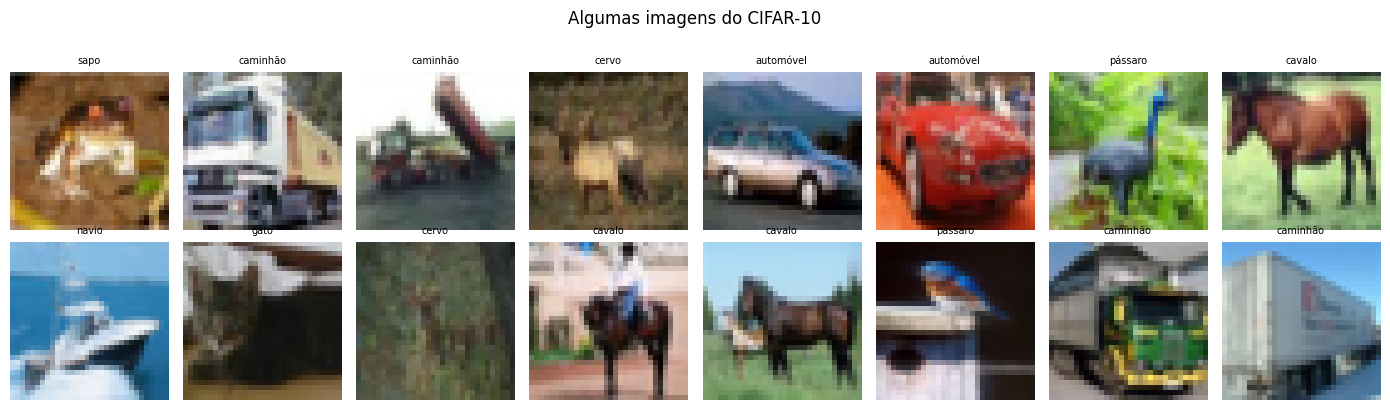

In [9]:
def denormalize(tensor, mean, std):
    """Desfaz a normalização para visualizar a imagem original."""
    mean = torch.tensor(mean).view(3, 1, 1)
    std  = torch.tensor(std).view(3, 1, 1)
    return torch.clamp(tensor * std + mean, 0, 1)


fig, axes = plt.subplots(2, 8, figsize=(14, 4))

for i, ax in enumerate(axes.flat):
    image, label = train_dataset[i]
    img_display = denormalize(image, CIFAR10_MEAN, CIFAR10_STD)
    ax.imshow(img_display.permute(1, 2, 0))  # [C, H, W] → [H, W, C]
    ax.set_title(CLASSES[label], fontsize=7)
    ax.axis("off")

plt.suptitle("Algumas imagens do CIFAR-10", y=1.02)
plt.tight_layout()
plt.show()


## 6. Entendendo o formato de uma imagem

Vamos pegar uma única imagem e analisar seu formato.

No PyTorch, imagens normalmente usam o formato:

```text
[canais, altura, largura]
```

Como o CIFAR-10 está em RGB, há **3 canais**: vermelho, verde e azul.

```text
imagem CIFAR-10: [3, 32, 32]
                  ↑   ↑   ↑
               canais  H   W
```

Isso é diferente do MNIST em escala de cinza, que usa `[1, 28, 28]`.


In [10]:
image, label = train_dataset[0]

print("Formato da imagem:", image.shape)   # [3, 32, 32]
print("Rótulo (índice):", label)
print("Classe:", CLASSES[label])
print("Menor valor no tensor:", image.min().item())
print("Maior valor no tensor:", image.max().item())


Formato da imagem: torch.Size([3, 32, 32])
Rótulo (índice): 6
Classe: sapo
Menor valor no tensor: -1.9894737005233765
Maior valor no tensor: 2.094278573989868


## 7. Criando os DataLoaders

Durante o treino, não processamos todas as imagens de uma vez.

O `DataLoader` organiza o dataset em pequenos grupos chamados **batches**.

Isso permite treinar o modelo de forma mais eficiente.

In [11]:
batch_size = 64

train_loader = DataLoader(
    train_dataset,
    batch_size=batch_size,
    shuffle=True
)

test_loader = DataLoader(
    test_dataset,
    batch_size=batch_size,
    shuffle=False
)

images_batch, labels_batch = next(iter(train_loader))

print("Formato do batch de imagens:", images_batch.shape)  # [64, 3, 32, 32]
print("Formato do batch de rótulos:", labels_batch.shape)


Formato do batch de imagens: torch.Size([64, 3, 32, 32])
Formato do batch de rótulos: torch.Size([64])


O formato do batch de imagens deve ser:

```text
[64, 3, 32, 32]
```

Isso significa:

```text
[quantidade de imagens, canais, altura, largura]
       64                  3      32      32
```

Cada imagem é representada por 3 matrizes 32×32 — uma por canal de cor.


## 8. Criando uma CNN (Rede Neural Convolucional)

Ao contrário de uma rede totalmente conectada (MLP), a CNN processa a imagem **com sua estrutura espacial preservada**.

### Por que não usar MLP para imagens coloridas?

Uma imagem CIFAR-10 tem `3 × 32 × 32 = 3.072` valores.  
Um MLP precisaria de uma camada `Linear(3072, 128)` — e não aproveita a estrutura espacial.

### A CNN usa operações de convolução:

```text
imagem [3, 32, 32]
   ↓
Conv2d(3 → 32)  + ReLU       → [32, 32, 32]
   ↓
MaxPool2d(2, 2)               → [32, 16, 16]
   ↓
Conv2d(32 → 64) + ReLU       → [64, 16, 16]
   ↓
MaxPool2d(2, 2)               → [64, 8, 8]
   ↓
Flatten                       → [64 × 8 × 8] = [4096]
   ↓
Linear(4096 → 256) + ReLU    → [256]
   ↓
Linear(256 → 10)              → saída com 10 valores
```

Cada `Conv2d` aprende **filtros** que detectam padrões visuais (bordas, texturas, formas).  
`MaxPool2d` reduz a resolução espacial e aumenta a invariância à posição.


In [12]:
class CNNSimples(nn.Module):
    def __init__(self, num_classes=10):
        super().__init__()

        # Bloco de extração de características
        self.features = nn.Sequential(
            nn.Conv2d(3, 32, kernel_size=3, padding=1),  # [B, 32, 32, 32]
            nn.ReLU(),
            nn.MaxPool2d(2, 2),                           # [B, 32, 16, 16]

            nn.Conv2d(32, 64, kernel_size=3, padding=1), # [B, 64, 16, 16]
            nn.ReLU(),
            nn.MaxPool2d(2, 2),                           # [B, 64,  8,  8]
        )

        # Cabeça de classificação
        self.classifier = nn.Sequential(
            nn.Flatten(),                        # [B, 64*8*8] = [B, 4096]
            nn.Linear(64 * 8 * 8, 256),
            nn.ReLU(),
            nn.Linear(256, num_classes)          # [B, 10]
        )

    def forward(self, x):
        x = self.features(x)
        return self.classifier(x)


model = CNNSimples(num_classes=10).to(device)
print(model)


CNNSimples(
  (features): Sequential(
    (0): Conv2d(3, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU()
    (2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (3): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (4): ReLU()
    (5): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (classifier): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Linear(in_features=4096, out_features=256, bias=True)
    (2): ReLU()
    (3): Linear(in_features=256, out_features=10, bias=True)
  )
)


## 9. Contando os parâmetros da CNN

Antes de treinar, vamos entender o tamanho do modelo.

Cada `Conv2d` e `Linear` possui pesos e biases que serão ajustados durante o treino.  
Esses são os **parâmetros treináveis** da rede.


In [13]:
total_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"Total de parâmetros treináveis: {total_params:,}")

# Teste de forward pass
images_batch, labels_batch = next(iter(train_loader))
images_batch = images_batch.to(device)

logits = model(images_batch)
print("Formato da saída do modelo:", logits.shape)  # [64, 10]


Total de parâmetros treináveis: 1,070,794
Formato da saída do modelo: torch.Size([64, 10])


A saída possui formato:

```text
[64, 10]
```

Isso significa:

- 64 imagens no batch;
- 10 valores de saída para cada imagem (um por classe).

Esses valores são chamados de **logits** — ainda não são probabilidades.  
Para transformar em probabilidades, usamos `softmax`.


In [14]:
probabilidades = torch.softmax(logits, dim=1)

print("Probabilidades da primeira imagem:")
print(probabilidades[0].detach().cpu())

print("Soma das probabilidades:", probabilidades[0].sum().item())
print("Classe prevista (antes do treino):", torch.argmax(probabilidades[0]).item(),
      "→", CLASSES[torch.argmax(probabilidades[0]).item()])


Probabilidades da primeira imagem:
tensor([0.0856, 0.1002, 0.0957, 0.0997, 0.1099, 0.1068, 0.0930, 0.1058, 0.0938,
        0.1094])
Soma das probabilidades: 1.0
Classe prevista (antes do treino): 4 → cervo


## 10. Definindo função de perda e otimizador

Para treinar a rede, precisamos de dois componentes principais:

### Função de perda

Mede o quanto o modelo está errando.

Para classificação multiclasse, usamos:

```python
nn.CrossEntropyLoss()
```

### Otimizador

Atualiza os pesos da rede para reduzir o erro.

Aqui usaremos:

```python
torch.optim.Adam()
```

In [15]:
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)

## 11. Criando uma função de treino

Agora vamos criar uma função para treinar o modelo por uma época.

Uma época significa que o modelo passou uma vez por todo o conjunto de treino.

In [16]:
def train_one_epoch(model, dataloader, criterion, optimizer, device):
    model.train()

    total_loss = 0.0
    correct = 0
    total = 0

    for images, labels in dataloader:
        images = images.to(device)
        labels = labels.to(device)

        # 1. Zera os gradientes acumulados
        optimizer.zero_grad()

        # 2. Forward: calcula a saída do modelo
        logits = model(images)

        # 3. Calcula o erro
        loss = criterion(logits, labels)

        # 4. Backward: calcula os gradientes
        loss.backward()

        # 5. Atualiza os pesos
        optimizer.step()

        # Métricas simples
        total_loss += loss.item() # Acumula a perda do batch
        preds = torch.argmax(logits, dim=1) # Obtém as classes previstas
        correct += (preds == labels).sum().item() # Conta acertos
        total += labels.size(0) # Conta o total de amostras processadas

    avg_loss = total_loss / len(dataloader) # Calcula a perda média do epoch
    accuracy = correct / total # Calcula a acurácia do epoch

    return avg_loss, accuracy

## 12. Criando uma função de avaliação

Na avaliação, não atualizamos os pesos.

Por isso usamos:

```python
model.eval()
torch.no_grad()
```

Isso deixa a execução mais eficiente e evita cálculos desnecessários de gradiente.

In [17]:
def evaluate(model, dataloader, criterion, device):
    model.eval()

    total_loss = 0.0
    correct = 0
    total = 0

    with torch.no_grad():
        for images, labels in dataloader:
            images = images.to(device)
            labels = labels.to(device)

            logits = model(images)
            loss = criterion(logits, labels)

            total_loss += loss.item()
            preds = torch.argmax(logits, dim=1)
            correct += (preds == labels).sum().item()
            total += labels.size(0)

    avg_loss = total_loss / len(dataloader)
    accuracy = correct / total

    return avg_loss, accuracy

## 13. Treinando o modelo

Vamos treinar por poucas épocas.

O CIFAR-10 é mais difícil que o MNIST — as imagens são coloridas e as classes são mais parecidas entre si.  
Com essa CNN simples esperamos atingir em torno de **60–70%** de acurácia em poucos epochs.

> Dica: para um treino mais rápido durante a aula, use 3–5 épocas. Para resultados melhores, tente 10+.


In [18]:
epochs = 3

for epoch in range(1, epochs + 1):
    train_loss, train_acc = train_one_epoch(
        model,
        train_loader,
        criterion,
        optimizer,
        device
    )

    test_loss, test_acc = evaluate(
        model,
        test_loader,
        criterion,
        device
    )

    print(
        f"Epoch {epoch}/{epochs} | "
        f"train_loss: {train_loss:.4f} | "
        f"train_acc: {train_acc:.4f} | "
        f"test_loss: {test_loss:.4f} | "
        f"test_acc: {test_acc:.4f}"
    )

Epoch 1/3 | train_loss: 1.3144 | train_acc: 0.5306 | test_loss: 1.0356 | test_acc: 0.6346
Epoch 2/3 | train_loss: 0.9158 | train_acc: 0.6764 | test_loss: 0.8793 | test_acc: 0.6928
Epoch 3/3 | train_loss: 0.7486 | train_acc: 0.7350 | test_loss: 0.8410 | test_acc: 0.7086


## 14. Fazendo uma predição manual

Agora vamos escolher uma imagem do conjunto de teste e pedir para o modelo prever a classe.

Essa etapa é muito importante didaticamente.

Aqui o aluno percebe que o modelo treinado já consegue receber uma imagem colorida e devolver uma classe do CIFAR-10.


Rótulo real: 3 → gato
Predição do modelo: 3 → gato
Probabilidade da classe prevista: 0.7373


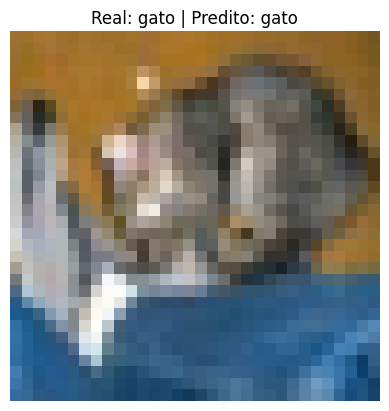

In [19]:
model.eval()

index = 0
image, true_label = test_dataset[index]

with torch.no_grad():
    x = image.unsqueeze(0).to(device)  # [1, 3, 32, 32]
    logits = model(x)
    probs = torch.softmax(logits, dim=1)
    predicted_label = torch.argmax(probs, dim=1).item()

print("Rótulo real:", true_label, "→", CLASSES[true_label])
print("Predição do modelo:", predicted_label, "→", CLASSES[predicted_label])
print("Probabilidade da classe prevista:", f"{probs[0, predicted_label].item():.4f}")

img_display = denormalize(image, CIFAR10_MEAN, CIFAR10_STD)
plt.imshow(img_display.permute(1, 2, 0))
plt.title(f"Real: {CLASSES[true_label]} | Predito: {CLASSES[predicted_label]}")
plt.axis("off")
plt.show()


## 15. Visualizando as probabilidades

Além da classe prevista, podemos observar a probabilidade atribuída a cada dígito.

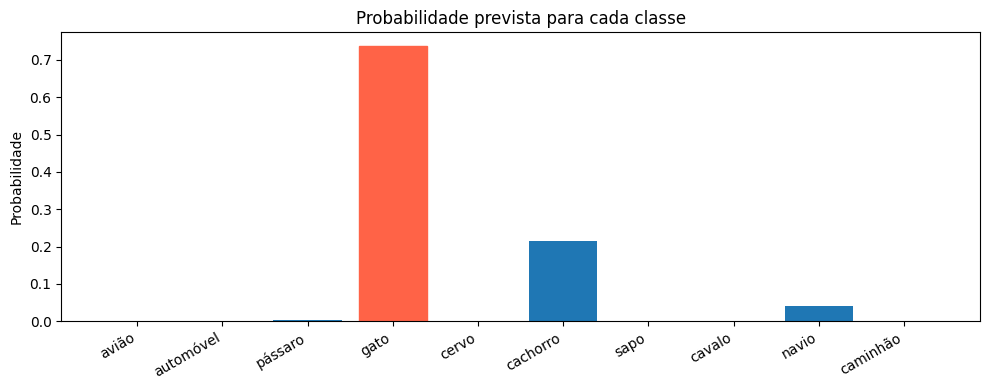

In [20]:
probs_cpu = probs.squeeze().cpu().detach()

plt.figure(figsize=(10, 4))
bars = plt.bar(range(10), probs_cpu)
bars[predicted_label].set_color("tomato")
plt.xticks(range(10), CLASSES, rotation=30, ha="right")
plt.ylabel("Probabilidade")
plt.title("Probabilidade prevista para cada classe")
plt.tight_layout()
plt.show()


## 16. Testando várias imagens

Vamos visualizar algumas imagens do conjunto de teste junto com a predição do modelo.

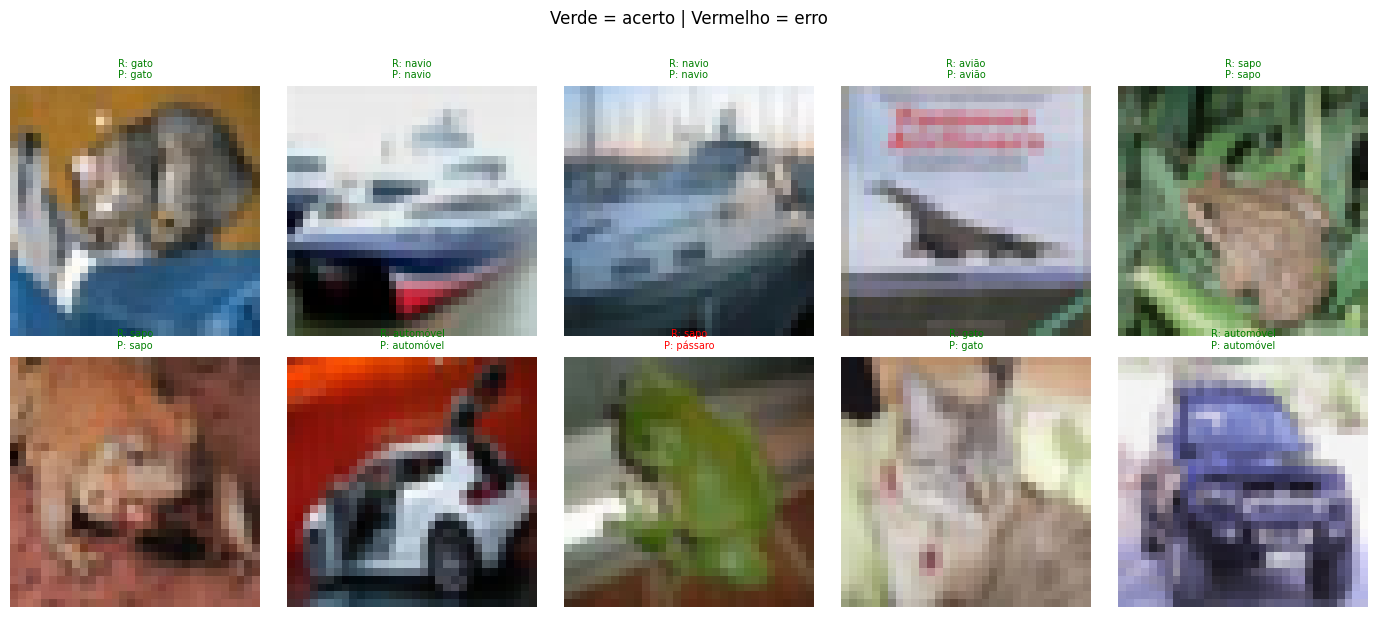

In [21]:
model.eval()

fig, axes = plt.subplots(2, 5, figsize=(14, 6))

for i, ax in enumerate(axes.flat):
    image, true_label = test_dataset[i]

    with torch.no_grad():
        x = image.unsqueeze(0).to(device)
        logits = model(x)
        pred = torch.argmax(logits, dim=1).item()

    img_display = denormalize(image, CIFAR10_MEAN, CIFAR10_STD)
    ax.imshow(img_display.permute(1, 2, 0))

    color = "green" if pred == true_label else "red"
    ax.set_title(f"R: {CLASSES[true_label]}\nP: {CLASSES[pred]}", fontsize=7, color=color)
    ax.axis("off")

plt.suptitle("Verde = acerto | Vermelho = erro", y=1.02)
plt.tight_layout()
plt.show()


## 17. Salvando o modelo treinado

Agora vamos salvar os pesos aprendidos pela CNN.

Essa é a **ponte para a próxima parte da aula**.

O notebook treina a CNN.  
A API carrega o modelo salvo e usa esse conhecimento para responder requisições com imagens novas.


In [22]:
artifacts_dir = Path("artifacts")
artifacts_dir.mkdir(exist_ok=True)

model_path = artifacts_dir / "cifar10_cnn.pt"

torch.save(model.state_dict(), model_path)

print("Modelo salvo em:", model_path)


Modelo salvo em: artifacts/cifar10_cnn.pt


## 18. Salvando metadados do modelo

Além dos pesos, é útil salvar algumas informações sobre o modelo.

Por exemplo:

- nome da arquitetura;
- classes possíveis;
- média e desvio padrão usados na normalização;
- tamanho esperado da imagem.

Esses metadados ajudam a API a repetir o mesmo pré-processamento usado no treino.

In [23]:
import json

metadata = {
    "model_name": "CNNSimples",
    "input_shape": [3, 32, 32],
    "classes": CLASSES,
    "normalization": {
        "mean": list(CIFAR10_MEAN),
        "std":  list(CIFAR10_STD)
    }
}

metadata_path = artifacts_dir / "metadata.json"

metadata_path.write_text(
    json.dumps(metadata, indent=2, ensure_ascii=False),
    encoding="utf-8"
)

print("Metadados salvos em:", metadata_path)
print(json.dumps(metadata, indent=2, ensure_ascii=False))


Metadados salvos em: artifacts/metadata.json
{
  "model_name": "CNNSimples",
  "input_shape": [
    3,
    32,
    32
  ],
  "classes": [
    "avião",
    "automóvel",
    "pássaro",
    "gato",
    "cervo",
    "cachorro",
    "sapo",
    "cavalo",
    "navio",
    "caminhão"
  ],
  "normalization": {
    "mean": [
      0.4914,
      0.4822,
      0.4465
    ],
    "std": [
      0.247,
      0.2435,
      0.2616
    ]
  }
}


## 19. Carregando o modelo salvo para conferir

Antes de encerrar, vamos simular o que a API fará depois:

1. criar a mesma arquitetura;
2. carregar os pesos salvos;
3. colocar o modelo em modo de avaliação;
4. fazer uma predição.

Rótulo real: navio
Predição do modelo carregado: navio


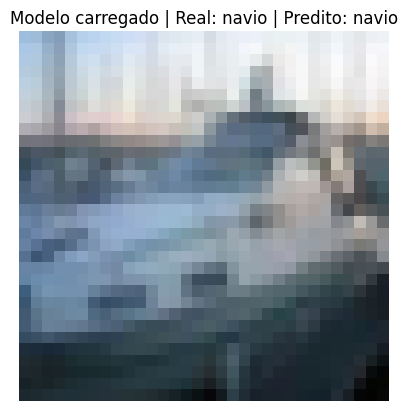

In [24]:
loaded_model = CNNSimples(num_classes=10).to(device)
loaded_model.load_state_dict(torch.load(model_path, map_location=device))
loaded_model.eval()

image, true_label = test_dataset[2]

with torch.no_grad():
    x = image.unsqueeze(0).to(device)
    logits = loaded_model(x)
    pred = torch.argmax(logits, dim=1).item()

print("Rótulo real:", CLASSES[true_label])
print("Predição do modelo carregado:", CLASSES[pred])

img_display = denormalize(image, CIFAR10_MEAN, CIFAR10_STD)
plt.imshow(img_display.permute(1, 2, 0))
plt.title(f"Modelo carregado | Real: {CLASSES[true_label]} | Predito: {CLASSES[pred]}")
plt.axis("off")
plt.show()


## 20. Fechamento da primeira parte

Nesta primeira parte, fizemos o ciclo completo de treinamento com CNN:

```text
dados CIFAR-10 → tensor [3, 32, 32] → CNN → treino → avaliação → predição → modelo salvo
```

Os arquivos gerados foram:

```text
artifacts/cifar10_cnn.pt      ← pesos da CNN treinada
artifacts/metadata.json       ← classes, normalização, shape esperado
```

Na próxima parte, vamos usar esses arquivos em uma API FastAPI.

A API receberá uma imagem via HTTP, aplicará o mesmo pré-processamento e devolverá a predição em JSON.

```text
imagem → POST /predict → [pré-processamento] → CNN → top-3 classes → JSON
```


## Desafio

Experimente modificar a CNN e observe o impacto na acurácia:

1. Adicione uma terceira camada de convolução (`Conv2d(64, 128, ...)`).
2. Adicione `nn.Dropout(0.5)` antes da última camada Linear.
3. Mude o `lr` (learning rate) do otimizador: teste `0.01`, `0.0001`.
4. Aumente o número de épocas para 10 e compare com 3 épocas.
5. Explique: por que a CNN consegue resultados melhores que um MLP para imagens?
6. Explique: por que a API precisa repetir o mesmo pré-processamento (normalização) usado no treino?
